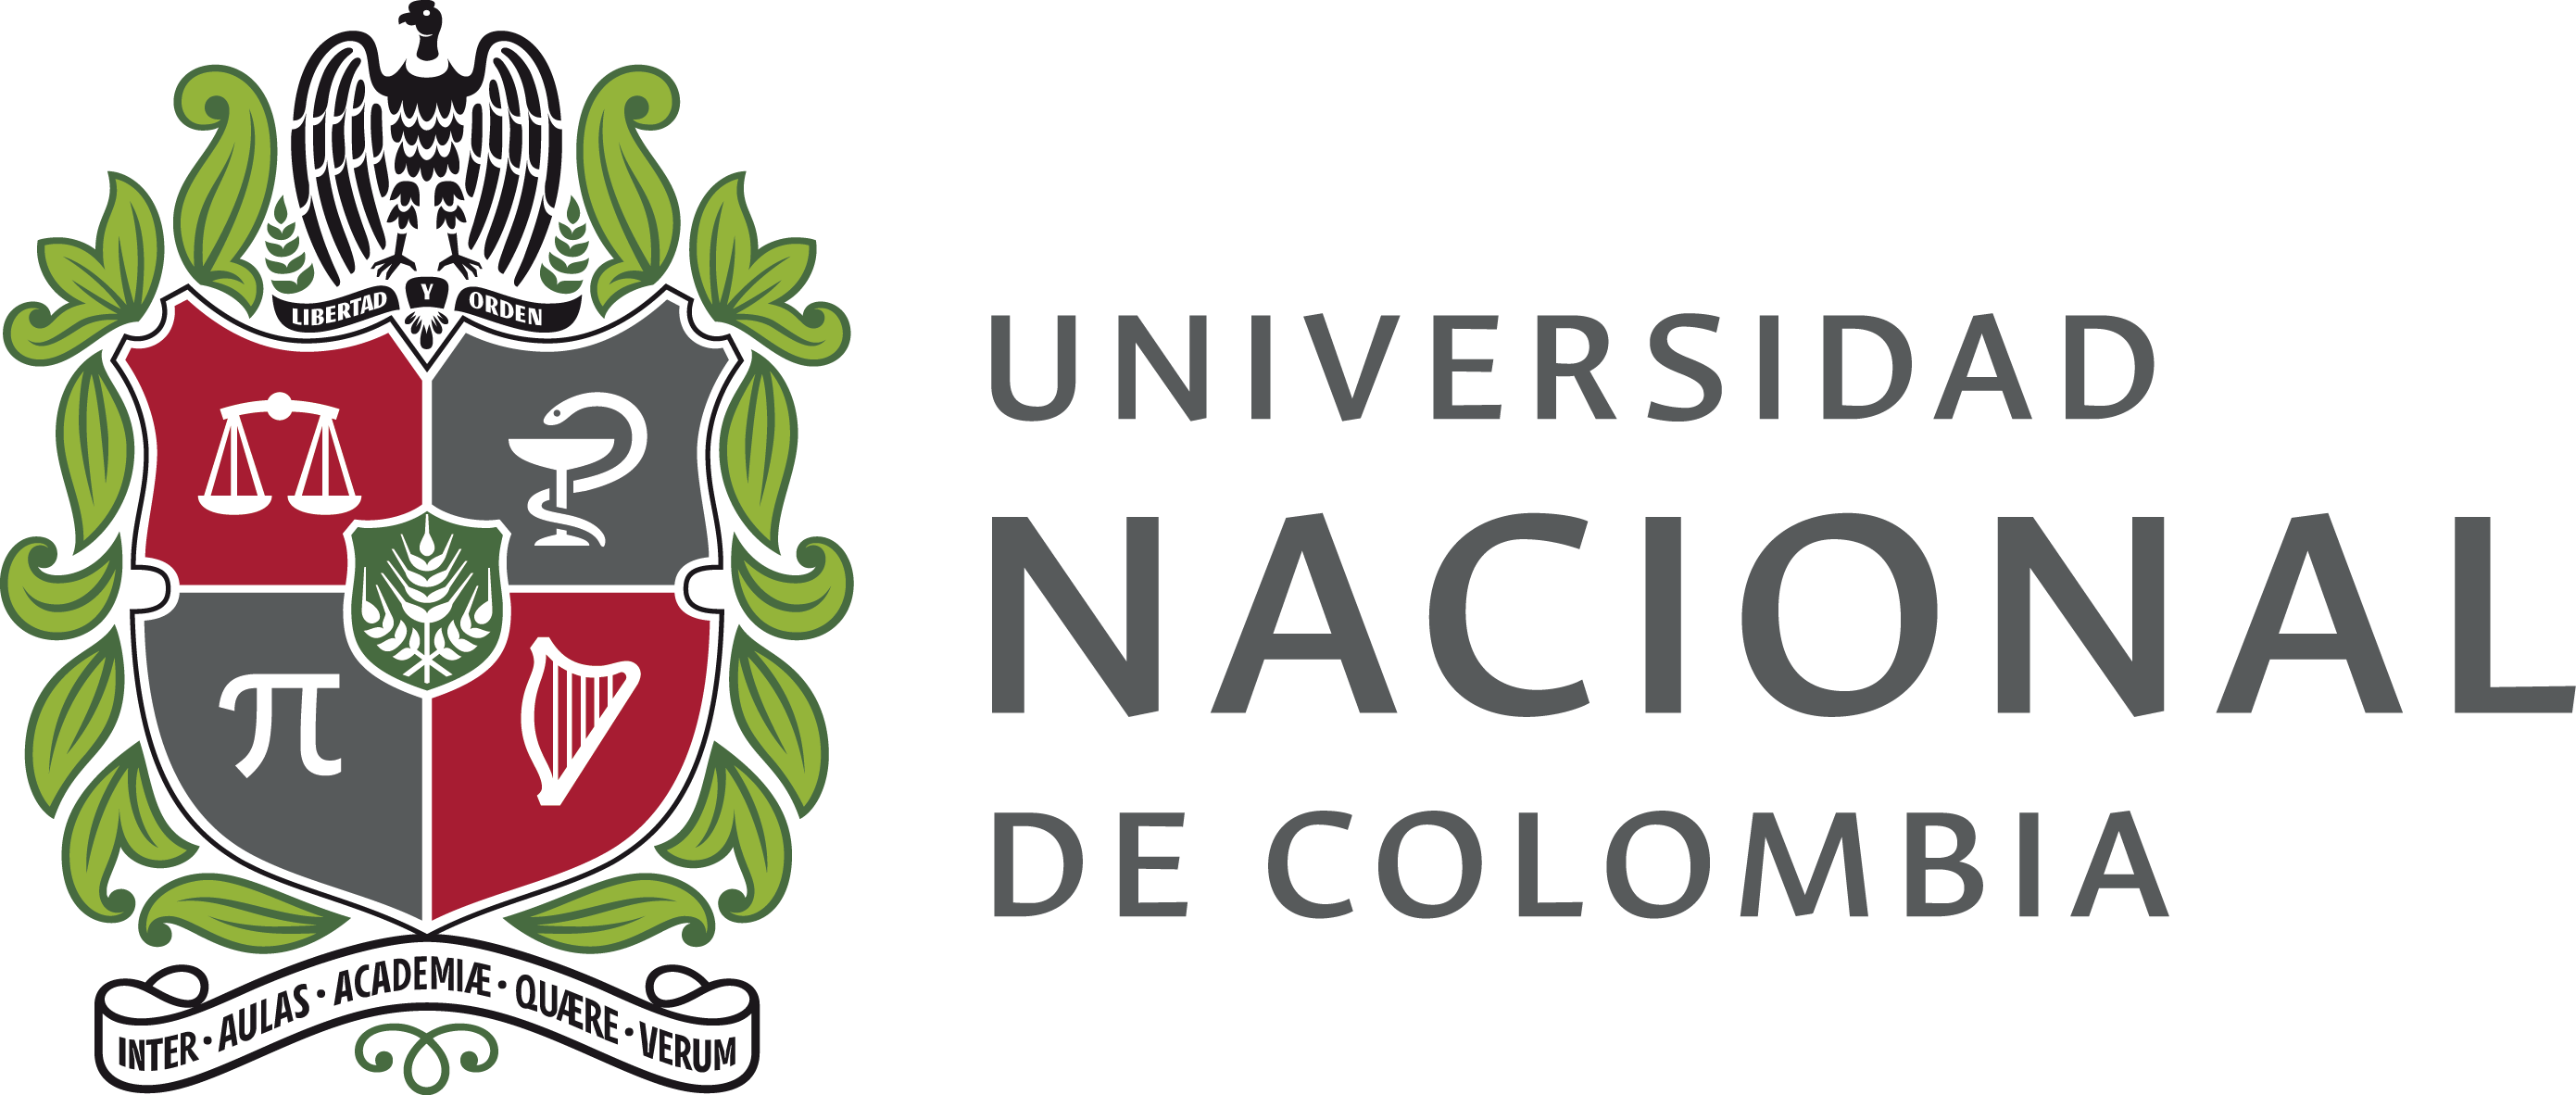
### **Universidad Nacional de Colombia sede Manizales**
#### Facultad de ingeniería y arquitectura
#### Departamento de ingeniería eléctrica, electrónica y computación
#### *Procesamiento digital de imágenes*

#### Profesor: Lucas Iturriago

### Instalar bibliotecas de Python

In [1]:
%%capture
!pip install roboflow

### Importar bibliotecas de Python

In [15]:
import os
import re
import glob
import time
import random
import numpy as np
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from roboflow import Roboflow
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.quantization as quantization
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2 as transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision.io import decode_image, ImageReadMode

### Descargar base de datos

In [3]:
rf = Roboflow(api_key="9smAmQgaD8pNOTsDMYKR")
project = rf.workspace("semantic-segmentation-844lw").project("raccoon-detection-cgctv")
version = project.version(5)
dataset = version.download("png-mask-semantic")           

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Raccoon-Detection-5 in png-mask-semantic:: 100%|██████████| 5266/5266 [00:00<00:00, 12307.15it/s]


### Fijar semilla

In [4]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

### Crear tf.Dataset

In [5]:
class SegmentationDataset(Dataset):
    def __init__(self, data_dir, image_size, num_classes, partition, augment=True):
        """
        PyTorch Dataset para segmentación semántica.

        Args:
            data_dir: Directorio raíz con las particiones (train/val/test)
            image_size: Tupla (height, width) para redimensionar imágenes
            num_classes: Número de clases para segmentación
            partition: 'train', 'val' o 'test'
            augment: Si aplicar data augmentation (solo en train)
        """
        self.data_dir = Path(data_dir)
        self.image_size = image_size
        self.num_classes = num_classes
        self.partition = partition
        self.augment = augment and (partition.lower() == 'train')

        # Cargar pares imagen-máscara
        partition_path = self.data_dir / self.partition
        
        supported_formats = ['*.png', '*.jpg', '*.jpeg']
        image_files = []
        
        for format_pattern in supported_formats:
            files = glob.glob(str(partition_path / format_pattern))
            image_files.extend(files)
        
        self.samples = []
        self.masks = []
        
        for img_path in tqdm(image_files, desc=f"Loading {partition} dataset"):
            img_path = Path(img_path)
            if '_mask' not in img_path.stem:
                mask_path = img_path.parent / f"{img_path.stem}_mask.png"
                if mask_path.exists():
                    self.samples.append(str(img_path))
                    self.masks.append(str(mask_path))
        
        # Ordenar alfabéticamente
        sorted_pairs = sorted(zip(self.samples, self.masks), 
                            key=lambda x: self._alphanumeric_key(x[0]))
        self.samples = [x[0] for x in sorted_pairs]
        self.masks = [x[1] for x in sorted_pairs]
        
        print(f"Found {len(self.samples)} image-mask pairs in {partition}")

    @staticmethod
    def _alphanumeric_key(s):
        """Clave para ordenamiento alfanumérico natural"""
        return [int(part) if part.isdigit() else part for part in re.split(r'(\d+)', s)]

    def _load_and_preprocess_image(self, image_path, mask_path):
        """Carga y preprocesa una imagen y su máscara"""
        # Leer imagen usando decode_image
        img = decode_image(image_path, mode=ImageReadMode.RGB)  # Shape: (3, H, W)
        
        # Redimensionar imagen con interpolación bilinear
        img = TF.resize(img, self.image_size, interpolation=TF.InterpolationMode.BILINEAR)
        
        # Normalizar a [0, 1]
        img = img.float() / 255.0
        
        # Leer máscara usando decode_image
        mask = decode_image(mask_path, mode=ImageReadMode.GRAY)  # Shape: (1, H, W)
        
        # Redimensionar máscara con interpolación nearest neighbor
        mask = TF.resize(mask, self.image_size, interpolation=TF.InterpolationMode.NEAREST)
        
        # Convertir a long y quitar dimensión de canal
        mask = mask.long().squeeze(0)  # Shape: (H, W)
        
        # Convertir a one-hot encoding
        mask_one_hot = torch.nn.functional.one_hot(mask, num_classes=self.num_classes)
        # Shape: (H, W, num_classes)
        
        # Permutar a (num_classes, H, W) para PyTorch
        mask_one_hot = mask_one_hot.permute(2, 0, 1).float()
        
        return img, mask_one_hot

    def _augment_image(self, image, mask):
        """Aplica data augmentation a imagen y máscara de forma sincronizada"""
        # Concatenar imagen y máscara para aplicar transformaciones geométricas juntas
        combined = torch.cat([image, mask], dim=0)  # Shape: (3 + num_classes, H, W)
        
        # Horizontal flip
        if random.random() > 0.5:
            combined = TF.hflip(combined)
        
        # Vertical flip
        if random.random() > 0.5:
            combined = TF.vflip(combined)
        
        # Separar imagen y máscara
        image = combined[:3, :, :]
        mask = combined[3:, :, :]
        
        # Augmentations solo para la imagen (no afectan la máscara)
        # Brightness
        if random.random() > 0.5:
            image = TF.adjust_brightness(image, brightness_factor=1.0 + random.uniform(-0.2, 0.2))
        
        # Contrast
        if random.random() > 0.5:
            image = TF.adjust_contrast(image, contrast_factor=random.uniform(0.8, 1.2))
        
        # Saturation
        if random.random() > 0.5:
            image = TF.adjust_saturation(image, saturation_factor=random.uniform(0.8, 1.2))
        
        # Gaussian noise
        if random.random() > 0.7:
            noise = torch.randn_like(image) * 0.02
            image = image + noise
        
        # Clip values
        image = torch.clamp(image, 0.0, 1.0)
        
        return image, mask

    def __len__(self):
        """Retorna el número de muestras"""
        return len(self.samples)

    def __getitem__(self, idx):
        """Obtiene una muestra del dataset"""
        image_path = self.samples[idx]
        mask_path = self.masks[idx]
        
        # Cargar y preprocesar
        image, mask = self._load_and_preprocess_image(image_path, mask_path)
        
        # Aplicar augmentation si corresponde
        if self.augment:
            image, mask = self._augment_image(image, mask)
        
        return image, mask


def SegmentationDataLoader(data_dir, batch_size, image_size, num_classes, 
                                partition, augment=True, num_workers=4, 
                                shuffle=None, pin_memory=True):
    """
    Crea un DataLoader para segmentación semántica.

    Args:
        data_dir: Directorio raíz con las particiones (train/val/test)
        batch_size: Tamaño del batch
        image_size: Tupla (height, width) para redimensionar imágenes
        num_classes: Número de clases para segmentación
        partition: 'train', 'val' o 'test'
        augment: Si aplicar data augmentation (solo en train)
        num_workers: Número de workers para cargar datos
        shuffle: Si hacer shuffle (default: True para train, False para val/test)
        pin_memory: Si usar pin_memory para GPU

    Returns:
        DataLoader de PyTorch
    """
    # Crear dataset
    dataset = SegmentationDataset(
        data_dir=data_dir,
        image_size=image_size,
        num_classes=num_classes,
        partition=partition,
        augment=augment
    )
    
    # Determinar shuffle automáticamente si no se especifica
    if shuffle is None:
        shuffle = (partition.lower() == 'train')
    
    # Crear dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=(partition.lower() == 'train')  # Drop last batch solo en train
    )
    
    return dataloader

In [6]:
# Crear dataloader para entrenamiento
train_loader = SegmentationDataLoader(
    data_dir='./Raccoon-Detection-5',
    batch_size=32,
    image_size=(128, 128),
    partition='train',
    augment=True,
    num_classes=2
)

# Crear dataloader para validación
val_loader = SegmentationDataLoader(
    data_dir='./Raccoon-Detection-5',
    batch_size=32,
    image_size=(128, 128),
    partition='valid',
    augment=False,
    num_classes=2
)

# Crear dataloader para evaluación
test_loader = SegmentationDataLoader(
    data_dir='./Raccoon-Detection-5',
    batch_size=1,
    image_size=(128, 128),
    partition='test',
    augment=False,
    num_classes=2
)

Loading train dataset: 100%|██████████| 4054/4054 [00:00<00:00, 118018.20it/s]


Found 2027 image-mask pairs in train


Loading valid dataset: 100%|██████████| 802/802 [00:00<00:00, 97925.29it/s]


Found 401 image-mask pairs in valid


Loading test dataset: 100%|██████████| 402/402 [00:00<00:00, 89387.17it/s]

Found 201 image-mask pairs in test


### Crear y definir modelo

In [7]:
class ResidualBlock(nn.Module):
    """Bloque residual para encoder"""
    def __init__(self, in_channels, out_channels, stride=1, name=None):
        super(ResidualBlock, self).__init__()
        self.name = name
        
        # Rama principal
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, 
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu1 = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, 
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Proyección si cambia dimensión
        self.projection = None
        if stride != 1 or in_channels != out_channels:
            self.projection = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, 
                         stride=stride, padding=0, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        
        self.relu_out = nn.ReLU(inplace=True)
    
    def forward(self, x):
        shortcut = x
        
        # Rama principal
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        # Proyección si es necesario
        if self.projection is not None:
            shortcut = self.projection(shortcut)
        
        # Suma + activación
        out = out + shortcut
        out = self.relu_out(out)
        
        return out


class DecoderBlock(nn.Module):
    """Bloque decoder con skip connections"""
    def __init__(self, in_channels, skip_channels, out_channels, name=None):
        super(DecoderBlock, self).__init__()
        self.name = name
        
        # Upsampling
        self.upsample = nn.ConvTranspose2d(in_channels, out_channels, 
                                           kernel_size=2, stride=2, 
                                           padding=0, bias=False)
        self.bn_up = nn.BatchNorm2d(out_channels)
        self.relu_up = nn.ReLU(inplace=True)
        
        # Convoluciones después de concatenar
        # Nota: después de concatenar tendremos out_channels + skip_channels canales
        self.conv1 = nn.Conv2d(out_channels + skip_channels, out_channels, 
                               kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu1 = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, 
                               kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu2 = nn.ReLU(inplace=True)
    
    def forward(self, x, skip_connection):
        # Upsampling
        x = self.upsample(x)
        x = self.bn_up(x)
        x = self.relu_up(x)
        
        # Concatenar con skip connection
        x = torch.cat([x, skip_connection], dim=1)
        
        # Convoluciones
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        
        return x


class ResUNetSegmentation(nn.Module):
    """
    Modelo U-Net con encoder residual para segmentación semántica.
    La salida incluye softmax, NO son logits.
    
    Args:
        num_classes: Número de clases (Número de clases + fondo)
        input_channels: Número de canales de entrada (default: 3 para RGB)
        dropout_rate: Tasa de dropout
    """
    def __init__(self, num_classes=2, input_channels=3, dropout_rate=0.3):
        super(ResUNetSegmentation, self).__init__()
        
        self.num_classes = num_classes
        self.dropout_rate = dropout_rate
        
        # ============ ENCODER (Downsampling path) ============
        
        # Stem
        self.stem_conv = nn.Conv2d(input_channels, 64, kernel_size=7, 
                                   stride=2, padding=3, bias=False)
        self.stem_bn = nn.BatchNorm2d(64)
        self.stem_relu = nn.ReLU(inplace=True)
        self.stem_pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Block 1 - 64 filters
        self.enc_block1_1 = ResidualBlock(64, 64, stride=1, name="enc_block1_1")
        self.enc_block1_2 = ResidualBlock(64, 64, stride=1, name="enc_block1_2")
        
        # Block 2 - 128 filters
        self.enc_block2_1 = ResidualBlock(64, 128, stride=2, name="enc_block2_1")
        self.enc_block2_2 = ResidualBlock(128, 128, stride=1, name="enc_block2_2")
        
        # Block 3 - 256 filters
        self.enc_block3_1 = ResidualBlock(128, 256, stride=2, name="enc_block3_1")
        self.enc_block3_2 = ResidualBlock(256, 256, stride=1, name="enc_block3_2")
        
        # Block 4 - 512 filters (Bottleneck)
        self.enc_block4_1 = ResidualBlock(256, 512, stride=2, name="enc_block4_1")
        self.enc_block4_2 = ResidualBlock(512, 512, stride=1, name="enc_block4_2")
        
        # Dropout en el bottleneck
        self.bottleneck_dropout = nn.Dropout2d(p=dropout_rate)
        
        # ============ DECODER (Upsampling path) ============
        
        # Decoder Block 1
        self.dec_block1 = DecoderBlock(512, 256, 256, name="dec_block1")
        
        # Decoder Block 2
        self.dec_block2 = DecoderBlock(256, 128, 128, name="dec_block2")
        
        # Decoder Block 3
        self.dec_block3 = DecoderBlock(128, 64, 64, name="dec_block3")
        
        # Decoder Block 4
        self.dec_block4 = DecoderBlock(64, 64, 64, name="dec_block4")
        
        # Upsampling final
        self.final_upsample = nn.ConvTranspose2d(64, 32, kernel_size=2, 
                                                 stride=2, padding=0, bias=False)
        self.final_bn = nn.BatchNorm2d(32)
        self.final_relu = nn.ReLU(inplace=True)
        
        # Convolución final
        self.final_conv = nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False)
        self.final_conv_bn = nn.BatchNorm2d(32)
        self.final_conv_relu = nn.ReLU(inplace=True)
        
        # Capa de salida con softmax
        self.output_conv = nn.Conv2d(32, num_classes, kernel_size=1, padding=0)
        self.softmax = nn.Softmax(dim=1)  # Softmax sobre el canal (dim=1)
    
    def forward(self, x):
        # ============ ENCODER ============
        
        # Stem
        x = self.stem_conv(x)
        x = self.stem_bn(x)
        x = self.stem_relu(x)
        skip1 = x  # 128x128x64 (si input es 256x256)
        
        x = self.stem_pool(x)
        
        # Block 1
        x = self.enc_block1_1(x)
        x = self.enc_block1_2(x)
        skip2 = x  # 64x64x64
        
        # Block 2
        x = self.enc_block2_1(x)
        x = self.enc_block2_2(x)
        skip3 = x  # 32x32x128
        
        # Block 3
        x = self.enc_block3_1(x)
        x = self.enc_block3_2(x)
        skip4 = x  # 16x16x256
        
        # Block 4 (Bottleneck)
        x = self.enc_block4_1(x)
        x = self.enc_block4_2(x)  # 8x8x512
        
        # Dropout
        x = self.bottleneck_dropout(x)
        
        # ============ DECODER ============
        
        # Decoder Block 1
        x = self.dec_block1(x, skip4)  # 16x16x256
        
        # Decoder Block 2
        x = self.dec_block2(x, skip3)  # 32x32x128
        
        # Decoder Block 3
        x = self.dec_block3(x, skip2)  # 64x64x64
        
        # Decoder Block 4
        x = self.dec_block4(x, skip1)  # 128x128x64
        
        # Upsampling final
        x = self.final_upsample(x)
        x = self.final_bn(x)
        x = self.final_relu(x)  # 256x256x32
        
        # Convolución final
        x = self.final_conv(x)
        x = self.final_conv_bn(x)
        x = self.final_conv_relu(x)
        
        # Capa de salida con softmax
        x = self.output_conv(x)
        x = self.softmax(x)  # Shape: (B, num_classes, H, W)
        
        return x


# Función helper para crear el modelo
def create_segmentation_model(num_classes=2, input_channels=3, dropout_rate=0.3):
    """
    Crea el modelo de segmentación.
    
    Args:
        num_classes: Número de clases (Número de clases + fondo)
        input_channels: Número de canales de entrada (default: 3 para RGB)
        dropout_rate: Tasa de dropout
    
    Returns:
        Modelo ResUNet con softmax en la salida
    """
    model = ResUNetSegmentation(
        num_classes=num_classes,
        input_channels=input_channels,
        dropout_rate=dropout_rate
    )
    return model

In [8]:
model = create_segmentation_model(
        num_classes=2,
        input_channels=3,
        dropout_rate=0.1)

In [9]:
print(model)

ResUNetSegmentation(
  (stem_conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_relu): ReLU(inplace=True)
  (stem_pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (enc_block1_1): ResidualBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu1): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu_out): ReLU(inplace=True)
  )
  (enc_block1_2): ResidualBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running

### Entrenamiento del modelo

In [10]:
# ============ DICE LOSS ============

class DiceLoss(nn.Module):
    """Dice Loss para segmentación con one-hot encoding"""
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    
    def forward(self, y_pred, y_true):
        """
        Args:
            y_pred: Predicciones del modelo (B, C, H, W) - ya con softmax
            y_true: Ground truth (B, C, H, W) - one-hot encoded
        """
        # Reshape a (B*H*W, C)
        y_pred_f = y_pred.permute(0, 2, 3, 1).contiguous().view(-1, y_pred.size(1))
        y_true_f = y_true.permute(0, 2, 3, 1).contiguous().view(-1, y_true.size(1))
        
        # Calcular intersección y unión por clase
        intersection = torch.sum(y_true_f * y_pred_f, dim=0)
        union = torch.sum(y_true_f, dim=0) + torch.sum(y_pred_f, dim=0)
        
        # Dice coefficient por clase
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        
        # Retornar 1 - dice promedio
        return 1 - torch.mean(dice)


# ============ MÉTRICAS PERSONALIZADAS ============

class DiceCoefficient:
    """Dice Coefficient como métrica (inverso del Dice Loss)"""
    def __init__(self, smooth=1e-6):
        self.smooth = smooth
        self.reset()
    
    def reset(self):
        """Reinicia las métricas acumuladas"""
        self.dice_sum = 0.0
        self.count = 0
    
    def update(self, y_pred, y_true):
        """
        Actualiza la métrica con un batch
        Args:
            y_pred: Predicciones (B, C, H, W)
            y_true: Ground truth (B, C, H, W)
        """
        # Reshape a (B*H*W, C)
        y_pred_f = y_pred.permute(0, 2, 3, 1).contiguous().view(-1, y_pred.size(1))
        y_true_f = y_true.permute(0, 2, 3, 1).contiguous().view(-1, y_true.size(1))
        
        intersection = torch.sum(y_true_f * y_pred_f, dim=0)
        union = torch.sum(y_true_f, dim=0) + torch.sum(y_pred_f, dim=0)
        
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        dice_mean = torch.mean(dice)
        
        self.dice_sum += dice_mean.item()
        self.count += 1
    
    def compute(self):
        """Calcula el valor final de la métrica"""
        if self.count == 0:
            return 0.0
        return self.dice_sum / self.count


class IoUScore:
    """IoU Score para segmentación"""
    def __init__(self, smooth=1e-6):
        self.smooth = smooth
        self.reset()
    
    def reset(self):
        """Reinicia las métricas acumuladas"""
        self.iou_sum = 0.0
        self.count = 0
    
    def update(self, y_pred, y_true):
        """
        Actualiza la métrica con un batch
        Args:
            y_pred: Predicciones (B, C, H, W)
            y_true: Ground truth (B, C, H, W)
        """
        # Reshape a (B*H*W, C)
        y_pred_f = y_pred.permute(0, 2, 3, 1).contiguous().view(-1, y_pred.size(1))
        y_true_f = y_true.permute(0, 2, 3, 1).contiguous().view(-1, y_true.size(1))
        
        intersection = torch.sum(y_true_f * y_pred_f, dim=0)
        union = torch.sum(y_true_f, dim=0) + torch.sum(y_pred_f, dim=0) - intersection
        
        iou = (intersection + self.smooth) / (union + self.smooth)
        iou_mean = torch.mean(iou)
        
        self.iou_sum += iou_mean.item()
        self.count += 1
    
    def compute(self):
        """Calcula el valor final de la métrica"""
        if self.count == 0:
            return 0.0
        return self.iou_sum / self.count


class PixelAccuracy:
    """Pixel Accuracy para segmentación"""
    def __init__(self):
        self.reset()
    
    def reset(self):
        """Reinicia las métricas acumuladas"""
        self.correct = 0
        self.total = 0
    
    def update(self, y_pred, y_true):
        """
        Actualiza la métrica con un batch
        Args:
            y_pred: Predicciones (B, C, H, W)
            y_true: Ground truth (B, C, H, W)
        """
        # Convertir a índices de clase
        pred_labels = torch.argmax(y_pred, dim=1)  # (B, H, W)
        true_labels = torch.argmax(y_true, dim=1)  # (B, H, W)
        
        self.correct += (pred_labels == true_labels).sum().item()
        self.total += true_labels.numel()
    
    def compute(self):
        """Calcula el valor final de la métrica"""
        if self.total == 0:
            return 0.0
        return self.correct / self.total

In [11]:
class TrainingHistory:
    """Clase para almacenar el historial de entrenamiento (similar a Keras)"""
    def __init__(self):
        self.history = {
            'loss': [],
            'pixel_accuracy': [],
            'dice_coef': [],
            'mean_iou': [],
            'val_loss': [],
            'val_pixel_accuracy': [],
            'val_dice_coef': [],
            'val_mean_iou': []
        }
    
    def update(self, metrics_dict):
        """Actualiza el historial con las métricas de una época"""
        for key, value in metrics_dict.items():
            if key in self.history:
                self.history[key].append(value)

class EarlyStopping:
    """Early stopping para detener el entrenamiento cuando no hay mejora"""
    def __init__(self, patience=15, min_delta=0, mode='max', verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_state = None
        
    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        elif self._is_improvement(score):
            self.best_score = score
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
        else:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print('Early stopping triggered')
    
    def _is_improvement(self, score):
        if self.mode == 'min':
            return score < (self.best_score - self.min_delta)
        else:
            return score > (self.best_score + self.min_delta)
    
    def restore_best_weights(self, model):
        """Restaura los mejores pesos del modelo"""
        if self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)
            if self.verbose:
                print('Restored best model weights')


# ============ TRAINING FUNCTIONS ============

def train_epoch(model, dataloader, criterion, optimizer, device):
    """Entrena una época"""
    model.train()
    
    # Inicializar métricas
    running_loss = 0.0
    pixel_acc_metric = PixelAccuracy()
    dice_metric = DiceCoefficient()
    iou_metric = IoUScore()
    num_batches = 0
    
    pbar = tqdm(dataloader, desc='Training')
    for images, masks in pbar:
        images, masks = images.to(device), masks.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)  # Ya tiene softmax
        loss = criterion(outputs, masks)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Actualizar métricas
        running_loss += loss.item()
        pixel_acc_metric.update(outputs.detach(), masks)
        dice_metric.update(outputs.detach(), masks)
        iou_metric.update(outputs.detach(), masks)
        num_batches += 1
        
        # Actualizar progress bar
        pbar.set_postfix({
            'loss': running_loss / num_batches,
            'dice': dice_metric.compute()
        })
    
    # Calcular métricas finales
    epoch_loss = running_loss / num_batches
    epoch_pixel_acc = pixel_acc_metric.compute()
    epoch_dice = dice_metric.compute()
    epoch_iou = iou_metric.compute()
    
    return epoch_loss, epoch_pixel_acc, epoch_dice, epoch_iou


def validate_epoch(model, dataloader, criterion, device):
    """Valida una época"""
    model.eval()
    
    # Inicializar métricas
    running_loss = 0.0
    pixel_acc_metric = PixelAccuracy()
    dice_metric = DiceCoefficient()
    iou_metric = IoUScore()
    num_batches = 0
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation')
        for images, masks in pbar:
            images, masks = images.to(device), masks.to(device)
            
            # Forward pass
            outputs = model(images)  # Ya tiene softmax
            loss = criterion(outputs, masks)
            
            # Actualizar métricas
            running_loss += loss.item()
            pixel_acc_metric.update(outputs, masks)
            dice_metric.update(outputs, masks)
            iou_metric.update(outputs, masks)
            num_batches += 1
            
            # Actualizar progress bar
            pbar.set_postfix({
                'loss': running_loss / num_batches,
                'dice': dice_metric.compute()
            })
    
    # Calcular métricas finales
    epoch_loss = running_loss / num_batches
    epoch_pixel_acc = pixel_acc_metric.compute()
    epoch_dice = dice_metric.compute()
    epoch_iou = iou_metric.compute()
    
    return epoch_loss, epoch_pixel_acc, epoch_dice, epoch_iou


def train_model(model, train_loader, val_loader, epochs=50, learning_rate=1e-3,
                device='cuda', save_path='best_model.pth'):
    """
    Entrena el modelo (equivalente a model.fit de Keras)
    
    Args:
        model: Modelo PyTorch
        train_loader: DataLoader de entrenamiento
        val_loader: DataLoader de validación
        epochs: Número de épocas
        learning_rate: Learning rate inicial
        device: 'cuda' o 'cpu'
        save_path: Ruta para guardar el mejor modelo
    
    Returns:
        history: Objeto TrainingHistory con las métricas
    """
    # Mover modelo a device
    model = model.to(device)
    
    # Definir loss y optimizer (equivalente a model.compile)
    criterion = DiceLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Scheduler (equivalente a ReduceLROnPlateau)
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='max',  # Maximizar mean_iou
        factor=0.5,
        patience=3,
        min_lr=1e-6,
    )
    
    # Early stopping
    early_stopping = EarlyStopping(
        patience=15,
        mode='max',  # Maximizar mean_iou
        verbose=True
    )
    
    # Historial
    history = TrainingHistory()
    
    # Mejor IoU para guardar modelo
    best_val_iou = 0.0
    
    print(f"\nStarting training on {device}")
    print(f"Total epochs: {epochs}")
    print(f"Train batches: {len(train_loader)}")
    print(f"Val batches: {len(val_loader)}")
    print("-" * 80)
    
    # Loop de entrenamiento
    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        
        # Entrenar
        train_loss, train_pixel_acc, train_dice, train_iou = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        # Validar
        val_loss, val_pixel_acc, val_dice, val_iou = validate_epoch(
            model, val_loader, criterion, device
        )
        
        # Actualizar historial
        history.update({
            'loss': train_loss,
            'pixel_accuracy': train_pixel_acc,
            'dice_coef': train_dice,
            'mean_iou': train_iou,
            'val_loss': val_loss,
            'val_pixel_accuracy': val_pixel_acc,
            'val_dice_coef': val_dice,
            'val_mean_iou': val_iou
        })
        
        # Imprimir métricas
        print(f"\nResults:")
        print(f"  Train - Loss: {train_loss:.4f}, PixelAcc: {train_pixel_acc:.4f}, Dice: {train_dice:.4f}, IoU: {train_iou:.4f}")
        print(f"  Val   - Loss: {val_loss:.4f}, PixelAcc: {val_pixel_acc:.4f}, Dice: {val_dice:.4f}, IoU: {val_iou:.4f}")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.2e}")
        
        # Guardar mejor modelo (ModelCheckpoint)
        if val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_mean_iou': val_iou,
                'val_dice_coef': val_dice,
                'val_loss': val_loss,
            }, save_path)
            print(f"  Saved best model (val_iou: {val_iou:.4f})")
        
        # Actualizar learning rate
        scheduler.step(val_iou)
        
        # Early stopping
        early_stopping(val_iou, model)
        if early_stopping.early_stop:
            print(f"\nEarly stopping at epoch {epoch + 1}")
            early_stopping.restore_best_weights(model)
            break
    
    print("\n" + "=" * 80)
    print("Training completed!")
    print(f"Best validation IoU: {best_val_iou:.4f}")
    
    return history

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=50,
        learning_rate=1e-3,
        device=device,
        save_path='best_model.pth'
    )

Using device: cuda

Starting training on cuda
Total epochs: 50
Train batches: 63
Val batches: 13
--------------------------------------------------------------------------------

Epoch 1/50


Validation: 100%|██████████| 13/13 [00:00<00:00, 16.18it/s, loss=0.356, dice=0.644]



Results:
  Train - Loss: 0.3555, PixelAcc: 0.7913, Dice: 0.6445, IoU: 0.4977
  Val   - Loss: 0.3560, PixelAcc: 0.7445, Dice: 0.6440, IoU: 0.4916
  LR: 1.00e-03
  Saved best model (val_iou: 0.4916)

Epoch 2/50


Validation: 100%|██████████| 13/13 [00:00<00:00, 16.48it/s, loss=0.311, dice=0.689]



Results:
  Train - Loss: 0.2618, PixelAcc: 0.8418, Dice: 0.7382, IoU: 0.6062
  Val   - Loss: 0.3109, PixelAcc: 0.7436, Dice: 0.6891, IoU: 0.5386
  LR: 1.00e-03
  Saved best model (val_iou: 0.5386)

Epoch 3/50


...


Results:
  Train - Loss: 0.0583, PixelAcc: 0.9619, Dice: 0.9417, IoU: 0.8919
  Val   - Loss: 0.0800, PixelAcc: 0.9442, Dice: 0.9200, IoU: 0.8562
  LR: 1.25e-04
EarlyStopping counter: 3 out of 15

Epoch 49/50


Validation: 100%|██████████| 13/13 [00:00<00:00, 15.87it/s, loss=0.0771, dice=0.923]



Results:
  Train - Loss: 0.0588, PixelAcc: 0.9619, Dice: 0.9412, IoU: 0.8911
  Val   - Loss: 0.0771, PixelAcc: 0.9469, Dice: 0.9229, IoU: 0.8608
  LR: 1.25e-04
EarlyStopping counter: 4 out of 15

Epoch 50/50


Validation: 100%|██████████| 13/13 [00:00<00:00, 15.69it/s, loss=0.0749, dice=0.925]



Results:
  Train - Loss: 0.0566, PixelAcc: 0.9631, Dice: 0.9434, IoU: 0.8949
  Val   - Loss: 0.0749, PixelAcc: 0.9485, Dice: 0.9251, IoU: 0.8645
  LR: 6.25e-05
  Saved best model (val_iou: 0.8645)

Training completed!
Best validation IoU: 0.8645


### Evolución del entrenamiento

In [13]:
def plot_detailed_history(history, save_path='detailed_history.png'):
    """
    Grafica el historial de entrenamiento para segmentación semántica
    Args:
        history: Objeto TrainingHistory retornado por train_model()
        save_path: Ruta donde guardar la imagen
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    epochs = range(1, len(history.history['loss']) + 1)
    
    # Plot 1: Loss
    axes[0, 0].plot(epochs, history.history['loss'], 'b-o', label='Train', linewidth=2, markersize=4)
    axes[0, 0].plot(epochs, history.history['val_loss'], 'r-s', label='Val', linewidth=2, markersize=4)
    axes[0, 0].set_title('Dice Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Pixel Accuracy
    axes[0, 1].plot(epochs, history.history['pixel_accuracy'], 'b-o', label='Train', linewidth=2, markersize=4)
    axes[0, 1].plot(epochs, history.history['val_pixel_accuracy'], 'r-s', label='Val', linewidth=2, markersize=4)
    axes[0, 1].set_title('Pixel Accuracy', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('Accuracy', fontsize=12)
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Dice Coefficient
    axes[1, 0].plot(epochs, history.history['dice_coef'], 'b-o', label='Train', linewidth=2, markersize=4)
    axes[1, 0].plot(epochs, history.history['val_dice_coef'], 'r-s', label='Val', linewidth=2, markersize=4)
    axes[1, 0].set_title('Dice Coefficient', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('Dice Score', fontsize=12)
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Mean IoU
    axes[1, 1].plot(epochs, history.history['mean_iou'], 'b-o', label='Train', linewidth=2, markersize=4)
    axes[1, 1].plot(epochs, history.history['val_mean_iou'], 'r-s', label='Val', linewidth=2, markersize=4)
    axes[1, 1].set_title('Mean IoU', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch', fontsize=12)
    axes[1, 1].set_ylabel('IoU Score', fontsize=12)
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Detailed history plot saved to {save_path}")
    plt.show()

Detailed history plot saved to detailed_history.png


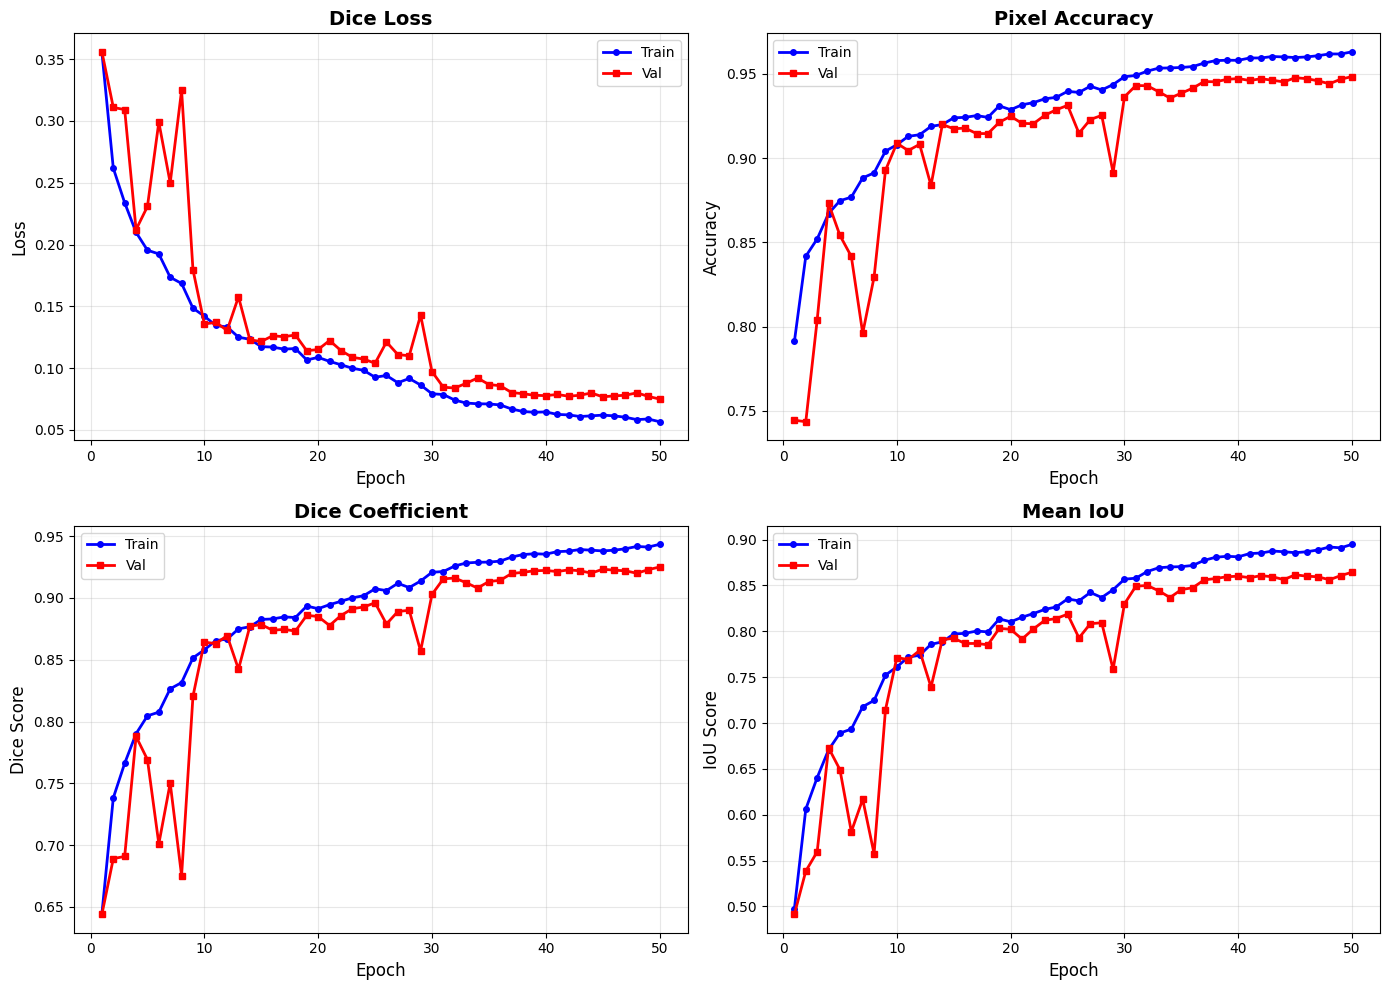

In [14]:
# Graficar historial detallado
plot_detailed_history(history)

### Convertir modelo a TorchScript
(en este caso cuantización dinámica, pero puede ser otra)

In [19]:
# Cargar el modelo entrenado
checkpoint = torch.load("best_model.pth")
model = create_segmentation_model(
    num_classes=2,
    dropout_rate=0.3,
    input_channels = 3
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Convertir a TorchScript
dummy_input = torch.rand(1, 3, 128, 128)

# Cuantización dinámica
quantized_model = torch.quantization.quantize_dynamic(
    model, {torch.nn.Linear}, dtype=torch.qint8
)
traced_quantized = torch.jit.trace(quantized_model, dummy_input)
traced_quantized.save("model_dynamic_quant.pt")

### Comparación de modelos

In [20]:
# Modelo PyTorch original
checkpoint = torch.load("best_model.pth")
model_pytorch = create_segmentation_model(
    num_classes=2,
    dropout_rate=0.3,
    input_channels=3
)
model_pytorch.load_state_dict(checkpoint['model_state_dict'])
model_pytorch.eval()

# Modelo cuantizado (TorchScript)
quantized_model = torch.jit.load("model_dynamic_quant.pt")
quantized_model.eval()

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_pytorch = model_pytorch.to(device)
quantized_model = quantized_model.to('cpu')  # Los modelos cuantizados suelen correr en CPU

In [21]:
def calculate_dice_coefficient(y_true, y_pred, smooth=1e-6):
    """
    Calcula el Dice Coefficient para máscaras de segmentación
    Args:
        y_true: Ground truth one-hot (B, C, H, W) o (C, H, W) - PyTorch format
        y_pred: Predicciones one-hot (B, C, H, W) o (C, H, W) - PyTorch format
        smooth: Factor de suavizado
    Returns:
        Dice coefficient (float)
    """
    # Convertir a numpy si es tensor
    if torch.is_tensor(y_true):
        y_true = y_true.cpu().numpy()
    if torch.is_tensor(y_pred):
        y_pred = y_pred.cpu().numpy()
    
    # Convertir de (C, H, W) a (H, W, C) para facilitar el cálculo
    if y_true.ndim == 3:
        y_true = np.transpose(y_true, (1, 2, 0))
    if y_pred.ndim == 3:
        y_pred = np.transpose(y_pred, (1, 2, 0))
    
    # Reshape a (H*W, C)
    y_true_f = y_true.reshape(-1, y_true.shape[-1])
    y_pred_f = y_pred.reshape(-1, y_pred.shape[-1])
    
    # Calcular intersección y unión
    intersection = np.sum(y_true_f * y_pred_f, axis=0)
    union = np.sum(y_true_f, axis=0) + np.sum(y_pred_f, axis=0)
    
    # Dice coefficient por clase
    dice = (2. * intersection + smooth) / (union + smooth)
    return np.mean(dice)

In [22]:
# ----- PyTorch Original -----
dice_scores_pytorch = []

start_pytorch = time.time()
with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="PyTorch Original"):
        images = images.to(device)
        
        # Predicción PyTorch
        preds_pytorch = model_pytorch(images)  # Shape: (B, C, H, W) con softmax
        
        # Mover a CPU para cálculo de métricas
        preds_pytorch = preds_pytorch.cpu()
        masks = masks.cpu()
        
        # Calcular Dice para cada imagen del batch
        for i in range(preds_pytorch.shape[0]):
            dice = calculate_dice_coefficient(masks[i], preds_pytorch[i])
            dice_scores_pytorch.append(dice)

end_pytorch = time.time()

# Dice Coefficient promedio PyTorch
dice_pytorch = np.mean(dice_scores_pytorch)


# ----- PyTorch Cuantizado (TorchScript) -----
dice_scores_quantized = []

start_quantized = time.time()
with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="PyTorch Quantized"):
        # Los modelos cuantizados corren en CPU
        images_cpu = images.to('cpu')
        masks_cpu = masks.to('cpu')
        
        # Predicción con modelo cuantizado
        preds_quantized = quantized_model(images_cpu)  # Shape: (B, C, H, W)
        
        # Calcular Dice para cada imagen del batch
        for i in range(preds_quantized.shape[0]):
            dice = calculate_dice_coefficient(masks_cpu[i], preds_quantized[i])
            dice_scores_quantized.append(dice)

end_quantized = time.time()

# Dice Coefficient promedio cuantizado
dice_quantized = np.mean(dice_scores_quantized)

PyTorch Quantized: 100%|██████████| 201/201 [00:11<00:00, 18.12it/s]


In [23]:
# Tiempos de inferencia
total_samples = len(dice_scores_pytorch)
pytorch_inference_time = (end_pytorch - start_pytorch) / total_samples
quantized_inference_time = (end_quantized - start_quantized) / total_samples

In [24]:
# Tamaño de los modelos
size_pytorch = os.path.getsize("best_model.pth") / (1024 * 1024)
size_quantized = os.path.getsize("model_dynamic_quant.pt") / (1024 * 1024)

In [25]:
print("\n" + "=" * 50)
print("======= RESULTADOS =======")
print("=" * 50)
print(f"\n DICE COEFFICIENT:")
print(f"  PyTorch Original:     {dice_pytorch:.4f}")
print(f"  PyTorch Quantized:    {dice_quantized:.4f}")
print(f"  Diferencia Dice:      {abs(dice_pytorch - dice_quantized):.4f}")

print(f"\n  TIEMPO DE INFERENCIA:")
print(f"  PyTorch Original:     {pytorch_inference_time*1000:.3f} ms")
print(f"  PyTorch Quantized:    {quantized_inference_time*1000:.3f} ms")
print(f"  Speedup:              {pytorch_inference_time/quantized_inference_time:.2f}x")

print(f"\n TAMAÑO DEL MODELO:")
print(f"  PyTorch Original:     {size_pytorch:.2f} MB")
print(f"  PyTorch Quantized:    {size_quantized:.2f} MB")
print(f"  Reducción de tamaño:  {(1 - size_quantized/size_pytorch)*100:.1f}%")

print("\n" + "=" * 50)


======= RESULTADOS =======

 DICE COEFFICIENT:
  PyTorch Original:     0.9177
  PyTorch Quantized:    0.9177
  Diferencia Dice:      0.0000

  TIEMPO DE INFERENCIA:
  PyTorch Original:     7.866 ms
  PyTorch Quantized:    55.208 ms
  Speedup:              0.14x

 TAMAÑO DEL MODELO:
  PyTorch Original:     164.25 MB
  PyTorch Quantized:    55.00 MB
  Reducción de tamaño:  66.5%

